In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
# from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor





In [ ]:
df = pd.read_csv("/content/crop-yield (1).csv")

In [ ]:
df.head()

,N,P,K,Soil_pH,Soil_Moisture,Soil_Type,Organic_Carbon,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Region,Altitude,Season,Crop_Type,Irrigation_Type,Fertilizer_Used,Pesticide_Used,Crop_Yield_ton_per_hectare
0,132,62,22,6.35,59.78,Clay,0.43,22.97,53.89,1305.68,7.73,15.96,Central,36,Rabi,Maize,Canal,223.48,23.36,11.42
1,122,71,66,5.98,25.54,Sandy,0.65,17.00,76.90,1942.05,9.25,12.60,North,1561,Rabi,Potato,Canal,161.54,4.42,23.19
2,44,35,104,8.07,25.87,Sandy,0.79,25.52,44.78,2216.20,8.50,15.63,North,1870,Rabi,Rice,Rainfed,184.62,6.29,7.94
3,136,96,113,4.83,42.97,Silt,0.45,18.59,31.89,607.18,8.75,5.49,East,765,Kharif,Sugarcane,Rainfed,274.02,2.72,72.53
4,101,34,42,5.84,48.01,Silt,0.69,22.74,46.27,483.47,8.00,7.44,Central,1143,Zaid,Wheat,Rainfed,72.69,15.37,6.72


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   N                           10000 non-null  int64  
 1   P                           10000 non-null  int64  
 2   K                           10000 non-null  int64  
 3   Soil_pH                     10000 non-null  float64
 4   Soil_Moisture               10000 non-null  float64
 5   Soil_Type                   10000 non-null  object 
 6   Organic_Carbon              10000 non-null  float64
 7   Temperature                 10000 non-null  float64
 8   Humidity                    10000 non-null  float64
 9   Rainfall                    10000 non-null  float64
 10  Sunlight_Hours              10000 non-null  float64
 11  Wind_Speed                  10000 non-null  float64
 12  Region                      10000 non-null  object 
 13  Altitude                    1000

In [ ]:
df.describe()

,N,P,K,Soil_pH,Soil_Moisture,Organic_Carbon,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Altitude,Fertilizer_Used,Pesticide_Used,Crop_Yield_ton_per_hectare
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,104.983000,56.809600,85.008700,6.504306,40.083748,0.958356,25.097402,59.894209,1546.694887,7.507868,9.503192,1103.357200,205.986246,12.525571,22.342801
std,43.291654,24.522962,37.541443,0.978698,14.461944,0.375027,8.719031,17.402450,718.865960,2.006472,4.911870,636.513856,83.607922,7.215035,23.986065
min,30.000000,15.000000,20.000000,4.800000,15.000000,0.300000,10.000000,30.010000,300.700000,4.000000,1.000000,0.000000,60.000000,0.000000,1.760000
25%,68.000000,35.000000,52.000000,5.670000,27.630000,0.630000,17.590000,44.830000,925.767500,5.770000,5.230000,550.000000,133.337500,6.310000,8.280000
50%,105.000000,57.000000,85.000000,6.520000,40.000000,0.960000,24.970000,59.550000,1548.550000,7.530000,9.520000,1106.000000,205.820000,12.440000,10.270000
75%,142.000000,78.000000,118.000000,7.350000,52.762500,1.290000,32.830000,75.037500,2165.452500,9.220000,13.710000,1655.250000,278.090000,18.760000,24.750000
max,179.000000,99.000000,149.000000,8.200000,64.990000,1.600000,40.000000,89.990000,2799.260000,11.000000,18.000000,2199.000000,349.960000,25.000000,80.990000


In [ ]:
df.groupby("Crop_Type")["Crop_Yield_ton_per_hectare"].mean()

,Crop_Yield_ton_per_hectare
Crop_Type,
Cotton,7.427941
Maize,10.076037
Potato,24.891012
Rice,9.402027
Sugarcane,74.830257
Wheat,8.724680


In [ ]:
df.groupby("Crop_Type")["Crop_Yield_ton_per_hectare"].agg(['mean', 'median', 'min', 'max', 'std', 'count'])

,mean,median,min,max,std,count
Crop_Type,,,,,,
Cotton,7.427941,7.420,1.76,12.86,1.727750,1666
Maize,10.076037,10.050,5.48,15.60,1.701917,1658
Potato,24.891012,24.830,20.32,30.27,1.681934,1670
Rice,9.402027,9.425,4.07,14.20,1.657081,1702
Sugarcane,74.830257,74.830,69.69,80.99,1.637562,1633
Wheat,8.724680,8.740,3.78,14.09,1.649251,1671


In [ ]:
# after visualizing correlations between variables
df = df[~df['Crop_Type'].isin(["Sugarcane", "Potato"])]

In [ ]:
import pandas as pd

# One-hot encoding
df_encoded = pd.get_dummies(
    df,
    columns=['Soil_Type', 'Region', 'Season', 'Crop_Type', 'Irrigation_Type'],
    drop_first=True,
    dtype = int
)

print(df_encoded.shape)
df_encoded.head()


(6697, 30)


,N,P,K,Soil_pH,Soil_Moisture,Organic_Carbon,Temperature,Humidity,Rainfall,Sunlight_Hours,...,Region_South,Region_West,Season_Rabi,Season_Zaid,Crop_Type_Maize,Crop_Type_Rice,Crop_Type_Wheat,Irrigation_Type_Drip,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler
0,132,62,22,6.35,59.78,0.43,22.97,53.89,1305.68,7.73,...,0,0,1,0,1,0,0,0,0,0
2,44,35,104,8.07,25.87,0.79,25.52,44.78,2216.20,8.50,...,0,0,1,0,0,1,0,0,1,0
4,101,34,42,5.84,48.01,0.69,22.74,46.27,483.47,8.00,...,0,0,0,1,0,0,1,0,1,0
5,50,29,22,6.87,32.73,1.20,13.88,68.91,1993.65,10.17,...,0,0,0,0,0,1,0,0,0,0
7,151,91,86,7.58,26.39,0.85,28.42,53.74,1499.40,8.24,...,0,0,0,0,0,1,0,0,1,0


In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6697 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   N                           6697 non-null   int64  
 1   P                           6697 non-null   int64  
 2   K                           6697 non-null   int64  
 3   Soil_pH                     6697 non-null   float64
 4   Soil_Moisture               6697 non-null   float64
 5   Organic_Carbon              6697 non-null   float64
 6   Temperature                 6697 non-null   float64
 7   Humidity                    6697 non-null   float64
 8   Rainfall                    6697 non-null   float64
 9   Sunlight_Hours              6697 non-null   float64
 10  Wind_Speed                  6697 non-null   float64
 11  Altitude                    6697 non-null   int64  
 12  Fertilizer_Used             6697 non-null   float64
 13  Pesticide_Used              6697 non-n

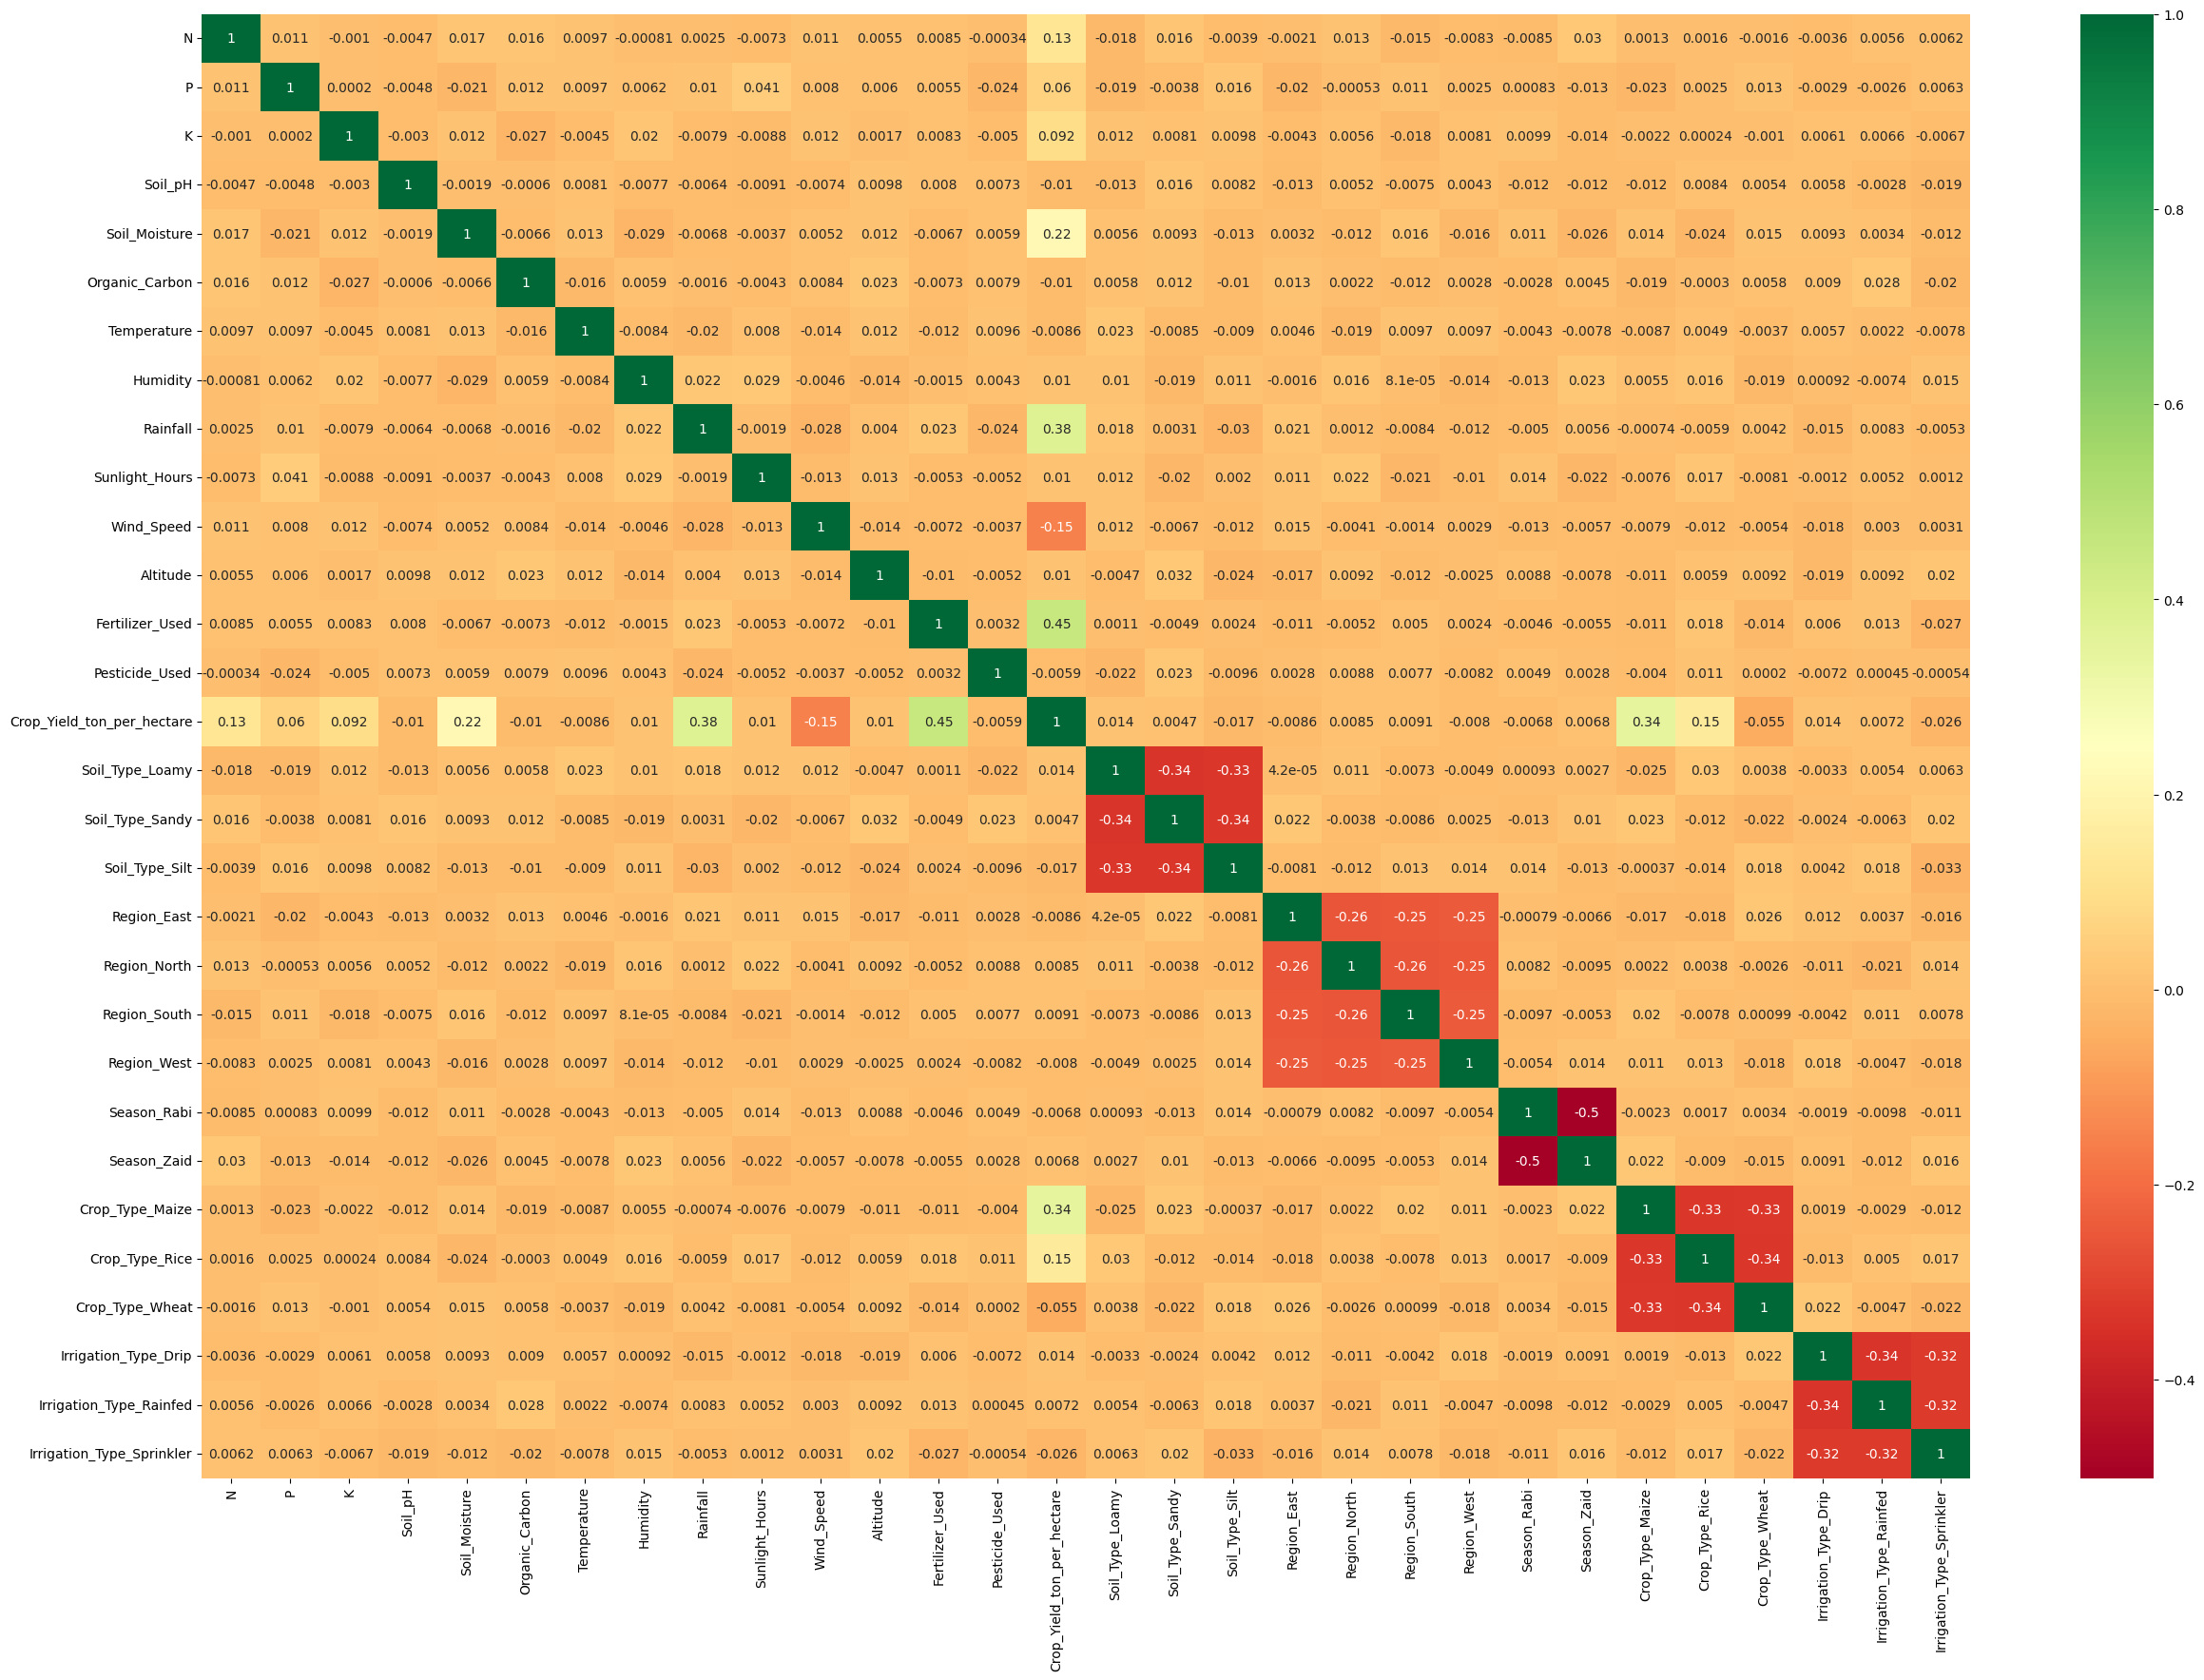

In [ ]:
# To check
plt.figure(figsize=(30,20))
sns.heatmap(df_encoded.corr(), cmap = 'RdYlGn' , annot=True)
plt.show()

In [ ]:
X = df_encoded.drop('Crop_Yield_ton_per_hectare', axis=1)
y = df_encoded['Crop_Yield_ton_per_hectare']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Test Shape:", X_test_scaled.shape)


Scaled Training Shape: (5357, 29)
Scaled Test Shape: (1340, 29)


In [ ]:
model = LinearRegression()

# Train
model.fit(X_train_scaled, y_train)

# Predict
y_pred_testt = model.predict(X_test_scaled)
y_pred_trainn = model.predict(X_train_scaled)

# Evaluation
r2_testt = r2_score(y_test, y_pred_testt)
r2_trainn = r2_score(y_train, y_pred_trainn)

mae_testt = mean_absolute_error(y_test, y_pred_testt)
mae_trainn = mean_absolute_error(y_train, y_pred_trainn)

rmse_testt = np.sqrt(mean_squared_error(y_test, y_pred_testt))
rmse_trainn = np.sqrt(mean_squared_error(y_train, y_pred_trainn))

print("Linear Regression Results:")
print("R2 Score:", r2_testt, r2_trainn)
print("MAE:", mae_testt, mae_trainn)
print("RMSE:", rmse_testt, rmse_trainn)







Linear Regression Results:
R2 Score: 0.6685299753683484 0.6932686540237719
MAE: 0.8992999081531897 0.8649757187284163
RMSE: 1.125245516538983 1.0766959717537765


In [ ]:
# Feature importance for Linear Regression
pd.DataFrame(model.coef_,
             index = X.columns)

,0
N,0.246365
P,0.119584
K,0.177968
Soil_pH,-0.023093
Soil_Moisture,0.438410
Organic_Carbon,0.004795
Temperature,0.011146
Humidity,0.008347
Rainfall,0.707906
Sunlight_Hours,0.017309


In [ ]:
# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    max_depth = 6
)

# Train
rf_model.fit(X_train_scaled, y_train)

# Predict
y_pred_train = rf_model.predict(X_train_scaled)
y_pred_test = rf_model.predict(X_test_scaled)

# Evaluation
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

print("Random Forest Results:")
print("R2 Score:", r2_test, r2_train)
print("MAE:", mae_test, mae_train)
print("RMSE:", rmse_test, rmse_train)




Random Forest Results:
R2 Score: 0.6008194609823514 0.6699540864371375
MAE: 0.9862918363454282 0.8963341995546024
RMSE: 1.2348375887715302 1.1168663029762995


In [ ]:
# Feature importance
importance = rf_model.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

            Feature  Importance
12  Fertilizer_Used    0.308907
8          Rainfall    0.201344
23  Crop_Type_Maize    0.188666
24   Crop_Type_Rice    0.108097
25  Crop_Type_Wheat    0.085267
4     Soil_Moisture    0.067061
10       Wind_Speed    0.008069
0                 N    0.007766
2                 K    0.007375
3           Soil_pH    0.006903


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring="r2")
print(scores.mean())

0.6118938715570774


In [ ]:
import joblib

# Save model
joblib.dump(model, "model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save column order
joblib.dump(X_train.columns.tolist(), "column.pkl")

['column.pkl']

In [ ]:
loaded = joblib.load("model.pkl")
print(type(loaded))

<class 'sklearn.linear_model._base.LinearRegression'>


In [ ]:
import joblib

# Load the linear regression model
loaded_model = joblib.load("model.pkl")
print(f"Type of loaded model: {type(loaded_model)}")

# Load the scaler
loaded_scaler = joblib.load("scaler.pkl")
print(f"Type of loaded scaler: {type(loaded_scaler)}")

# Load the column names
loaded_columns = joblib.load("column.pkl")
print(f"Type of loaded columns: {type(loaded_columns)}")
print(f"First 5 loaded column names: {loaded_columns[:5]}")

Type of loaded model: <class 'sklearn.linear_model._base.LinearRegression'>
Type of loaded scaler: <class 'sklearn.preprocessing._data.StandardScaler'>
Type of loaded columns: <class 'list'>
First 5 loaded column names: ['N', 'P', 'K', 'Soil_pH', 'Soil_Moisture']


# Task
**save_model_and_scaler**: Execute cell `_XZVXlee9vCZ` to save the Linear Regression model, scaler, and column names to disk.
**load_model_and_scaler**: Execute cell `199d77bf` to load the saved Linear Regression model, scaler, and column names to verify that the files are accessible.

## save_model_and_scaler

### Subtask:
Execute cell `_XZVXlee9vCZ` to save the Linear Regression model, scaler, and column names to disk.


**Reasoning**:
The user wants to execute cell `_XZVXlee9vCZ` to save the Linear Regression model, scaler, and column names to disk. I will provide the code from that cell.



In [ ]:
import joblib

# Save model
joblib.dump(model, "model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save column order
joblib.dump(X_train.columns.tolist(), "column.pkl")

['column.pkl']

**Reasoning**:
The previous step successfully saved the model, scaler, and column names. Now, I will execute cell `199d77bf` to load these files and verify they are accessible, as per the subtask instructions.



In [ ]:
import joblib

# Load the linear regression model
loaded_model = joblib.load("model.pkl")
print(f"Type of loaded model: {type(loaded_model)}")

# Load the scaler
loaded_scaler = joblib.load("scaler.pkl")
print(f"Type of loaded scaler: {type(loaded_scaler)}")

# Load the column names
loaded_columns = joblib.load("column.pkl")
print(f"Type of loaded columns: {type(loaded_columns)}")
print(f"First 5 loaded column names: {loaded_columns[:5]}")

Type of loaded model: <class 'sklearn.linear_model._base.LinearRegression'>
Type of loaded scaler: <class 'sklearn.preprocessing._data.StandardScaler'>
Type of loaded columns: <class 'list'>
First 5 loaded column names: ['N', 'P', 'K', 'Soil_pH', 'Soil_Moisture']


In [ ]:
import numpy as np
import pandas as pd
import joblib

# Load the necessary components
loaded_model = joblib.load("model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_columns = joblib.load("column.pkl")

# Define ranges for numerical features based on df.describe() or general knowledge
# Note: These ranges are approximate and based on the earlier df.describe() output for the filtered data.
npk_range = (30, 179) # N, P, K
soil_ph_range = (4.8, 8.2)
soil_moisture_range = (15, 65)
organic_carbon_range = (0.3, 1.6)
temperature_range = (10, 40)
humidity_range = (30, 90)
rainfall_range = (300, 2800)
sunlight_hours_range = (4, 11)
wind_speed_range = (1, 18)
altitude_range = (0, 2200)
fertilizer_used_range = (60, 350)
pesticide_used_range = (0, 25)

# Define possible categories for categorical features
soil_types = ['Clay', 'Loamy', 'Sandy', 'Silt'] # From df_encoded columns
regions = ['Central', 'East', 'North', 'South', 'West'] # From df_encoded columns
seasons = ['Kharif', 'Rabi', 'Zaid'] # From df_encoded columns
crop_types = ['Cotton', 'Maize', 'Rice', 'Wheat'] # From df_encoded columns, excluding Sugarcane, Potato
irrigation_types = ['Canal', 'Drip', 'Rainfed', 'Sprinkler'] # From df_encoded columns

# Generate a random input data point
random_input_data = {
    'N': np.random.randint(npk_range[0], npk_range[1] + 1),
    'P': np.random.randint(npk_range[0], npk_range[1] + 1),
    'K': np.random.randint(npk_range[0], npk_range[1] + 1),
    'Soil_pH': np.random.uniform(soil_ph_range[0], soil_ph_range[1]),
    'Soil_Moisture': np.random.uniform(soil_moisture_range[0], soil_moisture_range[1]),
    'Organic_Carbon': np.random.uniform(organic_carbon_range[0], organic_carbon_range[1]),
    'Temperature': np.random.uniform(temperature_range[0], temperature_range[1]),
    'Humidity': np.random.uniform(humidity_range[0], humidity_range[1]),
    'Rainfall': np.random.uniform(rainfall_range[0], rainfall_range[1]),
    'Sunlight_Hours': np.random.uniform(sunlight_hours_range[0], sunlight_hours_range[1]),
    'Wind_Speed': np.random.uniform(wind_speed_range[0], wind_speed_range[1]),
    'Altitude': np.random.randint(altitude_range[0], altitude_range[1] + 1),
    'Fertilizer_Used': np.random.uniform(fertilizer_used_range[0], fertilizer_used_range[1]),
    'Pesticide_Used': np.random.uniform(pesticide_used_range[0], pesticide_used_range[1]),
    'Soil_Type': np.random.choice(soil_types),
    'Region': np.random.choice(regions),
    'Season': np.random.choice(seasons),
    'Crop_Type': np.random.choice(crop_types),
    'Irrigation_Type': np.random.choice(irrigation_types)
}

# Convert to DataFrame
input_df = pd.DataFrame([random_input_data])

# One-hot encode categorical features
input_df_encoded = pd.get_dummies(
    input_df,
    columns=['Soil_Type', 'Region', 'Season', 'Crop_Type', 'Irrigation_Type'],
    drop_first=True,
    dtype=int
)

# Align columns with the training data columns
# Fill missing columns (from one-hot encoding for categories not present in random_input_data) with 0
final_input_df = input_df_encoded.reindex(columns=[col for col in loaded_columns if col != 'Crop_Yield_ton_per_hectare'], fill_value=0)

# Scale the numerical features
scaled_input = loaded_scaler.transform(final_input_df)

# Make prediction
prediction = loaded_model.predict(scaled_input)[0]

print("\n========== GENERATED RANDOM INPUT ==========")
for key, value in random_input_data.items():
    print(f"{key}: {value}")

print("\n========== PREDICTED CROP YIELD ==========")
print(f"Predicted Crop Yield: {prediction:.2f} ton/hectare")

confidence = 'High' if prediction > 5 else 'Medium'
print(f"Confidence: {confidence}")


========== GENERATED RANDOM INPUT ==========
N: 172
P: 79
K: 144
Soil_pH: 4.999334688546134
Soil_Moisture: 37.82987719642101
Organic_Carbon: 0.3574963836097675
Temperature: 24.480732342787906
Humidity: 30.714137232361388
Rainfall: 1519.7078770590417
Sunlight_Hours: 5.258892935766834
Wind_Speed: 14.956156178455034
Altitude: 1359
Fertilizer_Used: 209.8612530936292
Pesticide_Used: 15.358408953221797
Soil_Type: Clay
Region: Central
Season: Rabi
Crop_Type: Wheat
Irrigation_Type: Drip

========== PREDICTED CROP YIELD ==========
Predicted Crop Yield: 7.82 ton/hectare
Confidence: High


In [ ]:
import numpy as np
import pandas as pd
import joblib

# Load the necessary components (if not already loaded)
# This assumes loaded_model, loaded_scaler, loaded_columns are still in memory
# If not, uncomment the lines below:
# loaded_model = joblib.load("model.pkl")
# loaded_scaler = joblib.load("scaler.pkl")
# loaded_columns = joblib.load("column.pkl")

# Define the specific input data provided by the user
specific_input_data = {
    'N': 33,
    'P': 61,
    'K': 86,
    'Soil_pH': 6.6750574286267685,
    'Soil_Moisture': 29.627512182626617,
    'Organic_Carbon': 1.4820281097878525,
    'Temperature': 22.523917857255224,
    'Humidity': 53.38463653943013,
    'Rainfall': 2221.681076178069,
    'Sunlight_Hours': 8.4044889674023,
    'Wind_Speed': 13.220770404779804,
    'Altitude': 49,
    'Fertilizer_Used': 298.9703054323254,
    'Pesticide_Used': 18.93016274403805,
    'Soil_Type': 'Clay',
    'Region': 'Central',
    'Season': 'Kharif',
    'Crop_Type': 'Wheat', # Changed as per user request
    'Irrigation_Type': 'Rainfed'
}

# Convert to DataFrame
input_df_specific = pd.DataFrame([specific_input_data])

# One-hot encode categorical features
input_df_specific_encoded = pd.get_dummies(
    input_df_specific,
    columns=['Soil_Type', 'Region', 'Season', 'Crop_Type', 'Irrigation_Type'],
    drop_first=True,
    dtype=int
)

# Align columns with the training data columns
# Fill missing columns with 0 for categories not present in the input
final_input_df_specific = input_df_specific_encoded.reindex(columns=[col for col in loaded_columns if col != 'Crop_Yield_ton_per_hectare'], fill_value=0)

# Scale the numerical features
scaled_input_specific = loaded_scaler.transform(final_input_df_specific)

# Make prediction
prediction_specific = loaded_model.predict(scaled_input_specific)[0]

print("\n========== SPECIFIC INPUT (Crop_Type: Wheat) ==========")
for key, value in specific_input_data.items():
    print(f"{key}: {value}")

print("\n========== PREDICTED CROP YIELD (Crop_Type: Wheat) ==========")
print(f"Predicted Crop Yield: {prediction_specific:.2f} ton/hectare")

confidence_specific = 'High' if prediction_specific > 5 else 'Medium'
print(f"Confidence: {confidence_specific}")


========== SPECIFIC INPUT (Crop_Type: Wheat) ==========
N: 33
P: 61
K: 86
Soil_pH: 6.6750574286267685
Soil_Moisture: 29.627512182626617
Organic_Carbon: 1.4820281097878525
Temperature: 22.523917857255224
Humidity: 53.38463653943013
Rainfall: 2221.681076178069
Sunlight_Hours: 8.4044889674023
Wind_Speed: 13.220770404779804
Altitude: 49
Fertilizer_Used: 298.9703054323254
Pesticide_Used: 18.93016274403805
Soil_Type: Clay
Region: Central
Season: Kharif
Crop_Type: Wheat
Irrigation_Type: Rainfed

========== PREDICTED CROP YIELD (Crop_Type: Wheat) ==========
Predicted Crop Yield: 8.09 ton/hectare
Confidence: High


## Summary:

### Data Analysis Key Findings
*   The Linear Regression model, `StandardScaler`, and feature column names were successfully saved to disk as `model.pkl`, `scaler.pkl`, and `column.pkl` respectively.
*   The saved components were successfully loaded, confirming their integrity and accessibility. The loaded model was identified as a `sklearn.linear_model._base.LinearRegression` object, the scaler as a `sklearn.preprocessing._data.StandardScaler` object, and the column names as a `list`.
*   The first five loaded column names matched the expected order: `['N', 'P', 'K', 'Soil_pH', 'Soil_Moisture']`.

### Insights or Next Steps
*   The successful saving and loading of the model and preprocessing tools ensures that the trained components can be persisted and reused, which is crucial for deployment or further analysis without retraining.
*   The next logical step would be to use these loaded components (model and scaler) to make predictions on new, unseen data, applying the same preprocessing steps as during training.
